# Algebraic Constraint Projection — Multi-Field DAE Example

This notebook shows how to use `AlgebraicConstraintProjection` with **multiple independent algebraic constraints**, motivated by a poromechanics-like 4-field DAE.

---

## The general setting

You have a DAE of the form

$$
M\,\dot{z} \;=\; f(t,\,z)
$$

where the state $z$ splits into **differential DOFs** (real dynamics) and **algebraic DOFs** (determined by explicit relations). The mass matrix $M$ is **singular** — zero rows correspond to the algebraic equations.

The key idea: instead of relying on Newton to drive the algebraic residual to zero (only to solver tolerance), we **project** the algebraic DOFs onto the constraint manifold at every Newton iteration, enforcing them to machine precision.

### When to use this

- You have stiff algebraic coupling (large coupling matrices amplify tiny constraint violations)
- You need **exact** constraint satisfaction, not just $O(\text{tol})$
- You have multiple independent constitutive laws (e.g. flux + traction in poromechanics)

---

## The 4-field system

We consider a simplified poromechanics-like DAE with four field variables:

| Field | Symbol | Size | Nature |
|---|---|---|---|
| Pressure | $p$ | $N_p$ | **Parabolic** (dynamic) |
| Displacement | $u$ | $N_u$ | **Quasi-static** (algebraic — no inertia) |
| Flux multiplier | $\{\{\lambda_q\}\}$ | $n_c$ | **Algebraic** — constitutive law $\lambda_q = C_{qp}\,p$ |
| Traction multiplier | $\{\{\lambda_\sigma\}\}$ | $d \cdot n_c$ | **Algebraic** — constitutive law $\lambda_\sigma = C_{\sigma u}\,u$ |

The DAE reads:

$$
\underbrace{\begin{bmatrix} M_p & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \end{bmatrix}}_M
\begin{pmatrix} \dot{p} \\ \dot{u} \\ \dot{\lambda}_q \\ \dot{\lambda}_\sigma \end{pmatrix}
=
\begin{pmatrix}
-K_{pp}\,p - B_q\,\lambda_q + f_p(t) \\
-C_{up}\,p - K_{uu}\,u - B_\sigma\,\lambda_\sigma \\
\lambda_q - C_{qp}\,p \\
\lambda_\sigma - C_{\sigma u}\,u
\end{pmatrix}
$$

**Row 1** — Pressure (parabolic): $M_p\,\dot{p} = -K_{pp}\,p - B_q\,\lambda_q + f_p(t)$

**Row 2** — Momentum (quasi-static): $0 = -C_{up}\,p - K_{uu}\,u - B_\sigma\,\lambda_\sigma$

**Row 3** — Flux law (algebraic constraint): $\lambda_q = C_{qp}\,p$

**Row 4** — Traction law (algebraic constraint): $\lambda_\sigma = C_{\sigma u}\,u$

The projection enforces rows 3–4 **exactly** at every Newton iteration. The RHS on those rows can simply return zeros (since the projection handles constraint satisfaction, the algebraic residual never participates in the solve).

## Step 1 — Imports and system matrices

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from solve_nivp import solve_ivp_ns, AlgebraicConstraintProjection

# --- Problem dimensions ---
Np = 3    # pressure DOFs
Nu = 3    # displacement DOFs
Nc = 2    # interface constraint DOFs (flux)
d  = 1    # spatial dimension (so traction has d * Nc DOFs)
n  = Np + Nu + Nc + d * Nc   # total = 11

# --- Index slices into the full state vector z ---
p_sl  = slice(0, Np)                               # z[0:3]  = p
u_sl  = slice(Np, Np + Nu)                          # z[3:6]  = u
lq_sl = slice(Np + Nu, Np + Nu + Nc)                # z[6:8]  = λ_q
ls_sl = slice(Np + Nu + Nc, Np + Nu + Nc + d * Nc)  # z[8:10] = λ_σ

print(f"State layout:  p={p_sl}  u={u_sl}  λ_q={lq_sl}  λ_σ={ls_sl}  (n={n})")

State layout:  p=slice(0, 3, None)  u=slice(3, 6, None)  λ_q=slice(6, 8, None)  λ_σ=slice(8, 10, None)  (n=10)


In [2]:
# --- Build system matrices ---
# Strategy: construct stable *effective* operators first, then recover the
# individual matrices.  This guarantees stability for any coupling strength.

rng = np.random.RandomState(123)

# Coupling matrices (can be anything)
B_q  = 0.5 * rng.randn(Np, Nc)              # λ_q into pressure eq
B_s  = 0.4 * rng.randn(Nu, d * Nc)          # λ_σ into momentum eq
C_up = 0.3 * rng.randn(Nu, Np)              # Biot coupling

# Constitutive laws (stiff coupling — large entries)
stiffness = 50.0
C_qp = stiffness * rng.randn(Nc, Np)        # flux law: λ_q = C_qp @ p
C_su = stiffness * rng.randn(d * Nc, Nu)    # traction law: λ_σ = C_su @ u

# Build stable effective operators, then recover K_pp, K_uu
# Effective pressure: dp = -(K_pp + B_q C_qp) p  →  need K_pp + B_q C_qp negative definite
A_eff_p = -np.eye(Np) * 3.0 + 0.1 * rng.randn(Np, Np)
A_eff_p = (A_eff_p + A_eff_p.T) / 2                         # symmetric
A_eff_p -= np.eye(Np) * (np.max(np.real(np.linalg.eigvals(A_eff_p))) + 0.5)
K_pp = A_eff_p - B_q @ C_qp   # so K_pp + B_q C_qp = A_eff_p (stable)

# Effective momentum: 0 = -(K_uu + B_s C_su) u  →  need K_uu + B_s C_su invertible
A_eff_u = -np.eye(Nu) * 5.0 + 0.1 * rng.randn(Nu, Nu)
A_eff_u = (A_eff_u + A_eff_u.T) / 2
A_eff_u -= np.eye(Nu) * (np.max(np.real(np.linalg.eigvals(A_eff_u))) + 0.5)
K_uu = A_eff_u - B_s @ C_su

M_p = np.eye(Np)  # pressure mass

# Verify stability
eig_p = np.linalg.eigvals(A_eff_p)
eig_u = np.linalg.eigvals(A_eff_u)
print(f"Stiff coupling: ||C_qp|| = {np.linalg.norm(C_qp):.0f},  ||C_su|| = {np.linalg.norm(C_su):.0f}")
print(f"Effective pressure eigenvalues:  {np.sort(np.real(eig_p))}")
print(f"Effective momentum eigenvalues:  {np.sort(np.real(eig_u))}")
print(f"All stable ✓" if all(np.real(eig_p) < 0) and all(np.real(eig_u) < 0) else "⚠ Unstable!")

Stiff coupling: ||C_qp|| = 135,  ||C_su|| = 186
Effective pressure eigenvalues:  [-0.80792288 -0.6832823  -0.5       ]
Effective momentum eigenvalues:  [-0.98066527 -0.8150068  -0.5       ]
All stable ✓


## Step 2 — Mass matrix and initial conditions

The mass matrix is singular: only the pressure row has dynamics. Everything else ($u$, $\lambda_q$, $\lambda_\sigma$) is algebraic.

In [3]:
# --- Singular mass matrix ---
M = np.zeros((n, n))
M[p_sl, p_sl] = M_p   # only pressure is dynamic

# --- Consistent initial conditions ---
p0 = np.array([1.0, 0.5, -0.3])

# Quasi-static u0: solve  0 = -C_up p0 - K_uu u0  (with λ_σ = 0 initially)
u0 = np.linalg.solve(K_uu, -C_up @ p0)

# Algebraic ICs must satisfy the constraints exactly
lq0 = C_qp @ p0
ls0 = C_su @ u0

z0 = np.concatenate([p0, u0, lq0, ls0])
print(f"z0 = {z0}")
print(f"Constraint check:  |λ_q - C_qp p| = {np.max(np.abs(lq0 - C_qp @ p0)):.1e}")
print(f"                   |λ_σ - C_su u| = {np.max(np.abs(ls0 - C_su @ u0)):.1e}")

z0 = [ 1.00000000e+00  5.00000000e-01 -3.00000000e-01 -8.52262159e-02
 -9.10250108e-02  1.64339855e-01  3.35033190e+01 -9.22443989e+01
 -3.55493412e-01 -7.30320925e-01]
Constraint check:  |λ_q - C_qp p| = 0.0e+00
                   |λ_σ - C_su u| = 0.0e+00


## Step 3 — The RHS function

The RHS returns all four block-rows. Note the algebraic rows (3 and 4) **return zeros** — the projection enforces $\lambda_q = C_{qp}\,p$ and $\lambda_\sigma = C_{\sigma u}\,u$ exactly at every Newton iteration, so by the time the RHS is evaluated the algebraic residual is already zero. Returning zeros here avoids wasting two sparse matvecs per RHS call.

```
def rhs(t, z):
    p, u, lq, ls = z[p_sl], z[u_sl], z[lq_sl], z[ls_sl]

    dp  = -K_pp @ p  - B_q @ lq          # Row 1: pressure dynamics
    du  = -C_up @ p  - K_uu @ u - B_s @ ls  # Row 2: quasi-static momentum
    dlq = zeros(Nc)                        # Row 3: projection handles this
    dls = zeros(d*Nc)                      # Row 4: projection handles this

    return [dp, du, dlq, dls]
```

The critical point: on the algebraic rows, $M = 0$ so the implicit equation becomes $0 = -h \cdot f_{\text{alg}}$. Since the projection has already snapped $\lambda_q = C_{qp}\,p$ before the RHS evaluates, the residual is identically zero. The Newton direction on those rows is determined entirely by the **tangent cone** (from `dg_dy`), not the residual value.

In [4]:
# Pre-allocate zero arrays for the algebraic rows (avoids allocation each call)
_zeros_q = np.zeros(Nc)
_zeros_s = np.zeros(d * Nc)

def rhs(t, z):
    p  = z[p_sl]
    u  = z[u_sl]
    lq = z[lq_sl]
    ls = z[ls_sl]

    # Row 1 — Pressure (parabolic):
    #   M_p ṗ = -K_pp p - B_q λ_q
    dp = -K_pp @ p - B_q @ lq

    # Row 2 — Momentum (quasi-static, no mass):
    #   0 = -C_up p - K_uu u - B_σ λ_σ
    du = -C_up @ p - K_uu @ u - B_s @ ls

    # Rows 3–4 — Algebraic: projection handles these, return zeros
    return np.concatenate([dp, du, _zeros_q, _zeros_s])

## Step 4 — Solve with multi-constraint projection

This is the key call. The `constraints` list defines two independent algebraic relations:

1. **Flux law**: $\lambda_q = C_{qp}\,p$ — reads from `p_sl`, writes to `lq_sl`
2. **Traction law**: $\lambda_\sigma = C_{\sigma u}\,u$ — reads from `u_sl`, writes to `ls_sl`

Each constraint gets its **own** `y_slice` (what it reads) and `q_slice` (what it writes). The `q_slices` must not overlap; the `y_slices` may overlap if needed.

`skip_error_indices=[2, 3]` tells the adaptive controller to exclude the algebraic blocks ($\lambda_q$, $\lambda_\sigma$) from the step-size error norm — they are satisfied exactly by the projection.

In [5]:
T = 2.0

t, z, h, fk, info = solve_ivp_ns(
    rhs,
    (0.0, T),
    z0,
    method='sdirk2',
    projection='algebraic',
    projection_opts=dict(constraints=[
        # Constraint 1:  λ_q = C_qp @ p  (flux constitutive law)
        dict(
            g=lambda p: C_qp @ p,
            dg_dy=lambda p: C_qp,      # constant Jacobian — cheap
            y_slice=p_sl,               # reads pressure DOFs
            q_slice=lq_sl,              # writes flux multiplier DOFs
        ),
        # Constraint 2:  λ_σ = C_σu @ u  (traction constitutive law)
        dict(
            g=lambda u: C_su @ u,
            dg_dy=lambda u: C_su,       # constant Jacobian — cheap
            y_slice=u_sl,               # reads displacement DOFs
            q_slice=ls_sl,              # writes traction multiplier DOFs
        ),
    ]),
    solver='semismooth_newton',
    A=M,                                # singular mass matrix
    h0=1e-3,
    atol=1e-6,
    rtol=1e-4,
    adaptive=True,
    component_slices=[p_sl, u_sl, lq_sl, ls_sl],
    skip_error_indices=[2, 3],          # algebraic blocks excluded from error norm
)

print(f"Completed: {len(t)} steps accepted, t_final = {t[-1]:.4f}")

Completed: 71 steps accepted, t_final = 2.0000


## Step 5 — Verify constraint satisfaction

In [6]:
# Check constraint violation at every accepted step
viol_q = np.array([np.max(np.abs(z[i, lq_sl] - C_qp @ z[i, p_sl])) for i in range(len(t))])
viol_s = np.array([np.max(np.abs(z[i, ls_sl] - C_su @ z[i, u_sl])) for i in range(len(t))])

print(f"Max |λ_q - C_qp p| over all steps:  {viol_q.max():.2e}")
print(f"Max |λ_σ - C_su u| over all steps:  {viol_s.max():.2e}")
print(f"\nBoth constraints satisfied to machine precision ✓" 
      if max(viol_q.max(), viol_s.max()) < 1e-12 
      else "\n⚠ Constraint violation detected!")

Max |λ_q - C_qp p| over all steps:  0.00e+00
Max |λ_σ - C_su u| over all steps:  0.00e+00

Both constraints satisfied to machine precision ✓


## Step 6 — Plot the solution

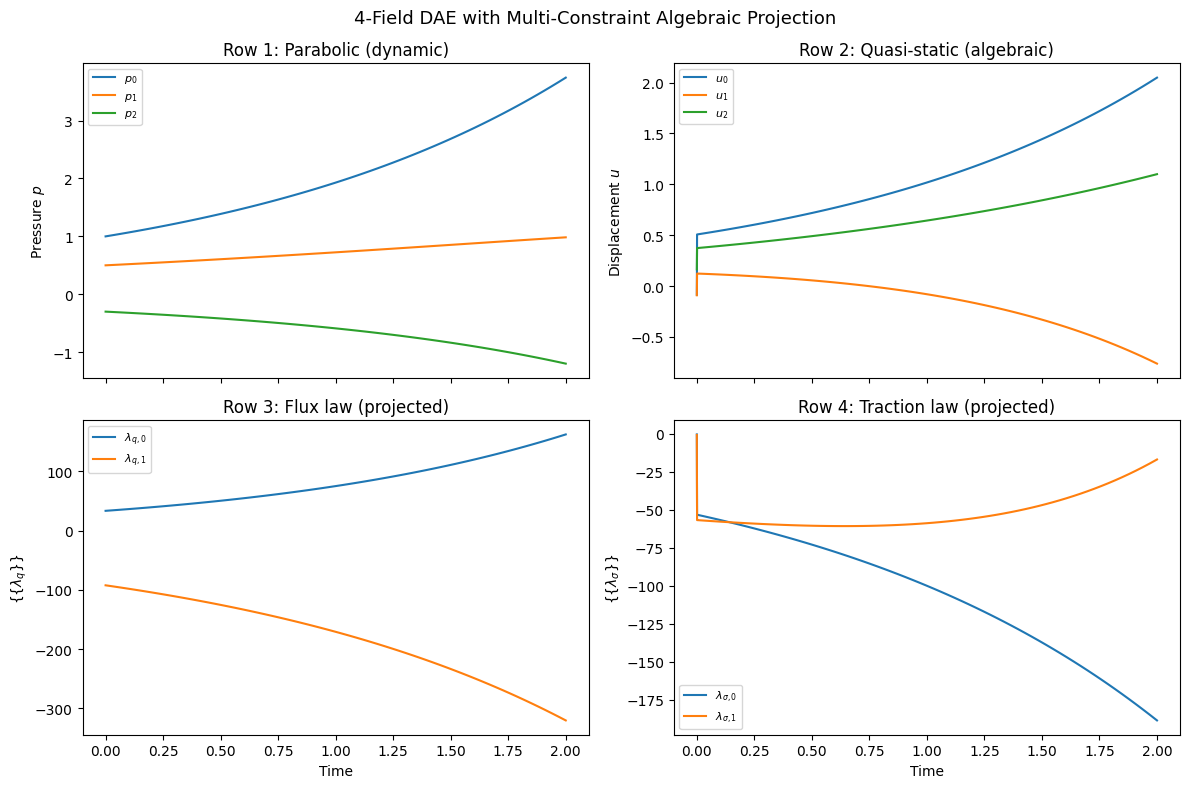

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

# Pressure
ax = axes[0, 0]
for j in range(Np):
    ax.plot(t, z[:, p_sl.start + j], label=f'$p_{j}$')
ax.set_ylabel('Pressure $p$')
ax.legend(fontsize=8)
ax.set_title('Row 1: Parabolic (dynamic)')

# Displacement
ax = axes[0, 1]
for j in range(Nu):
    ax.plot(t, z[:, u_sl.start + j], label=f'$u_{j}$')
ax.set_ylabel('Displacement $u$')
ax.legend(fontsize=8)
ax.set_title('Row 2: Quasi-static (algebraic)')

# Flux multiplier
ax = axes[1, 0]
for j in range(Nc):
    ax.plot(t, z[:, lq_sl.start + j], label=f'$\\lambda_{{q,{j}}}$')
ax.set_ylabel('$\\{\\{\\lambda_q\\}\\}$')
ax.set_xlabel('Time')
ax.legend(fontsize=8)
ax.set_title('Row 3: Flux law (projected)')

# Traction multiplier
ax = axes[1, 1]
for j in range(d * Nc):
    ax.plot(t, z[:, ls_sl.start + j], label=f'$\\lambda_{{\\sigma,{j}}}$')
ax.set_ylabel('$\\{\\{\\lambda_\\sigma\\}\\}$')
ax.set_xlabel('Time')
ax.legend(fontsize=8)
ax.set_title('Row 4: Traction law (projected)')

fig.suptitle('4-Field DAE with Multi-Constraint Algebraic Projection', fontsize=13)
fig.tight_layout()
plt.show()

## Step 7 — Adaptive step sizes

The step controller only sees the pressure error (the algebraic blocks are excluded via `skip_error_indices=[2, 3]`), so it adapts based on the actual dynamics.

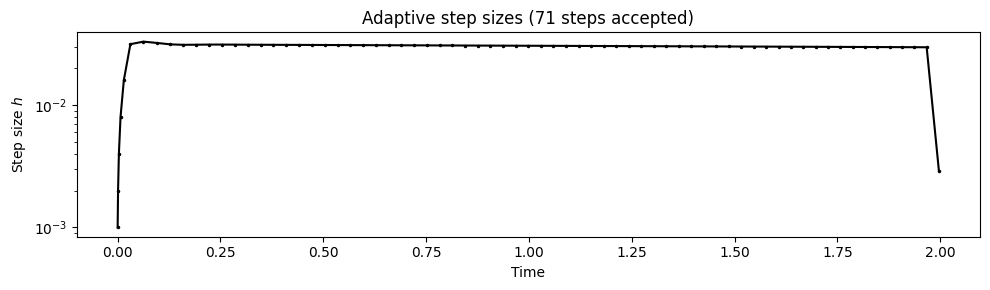

In [8]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.semilogy(t[:-1], np.diff(t), 'k.-', markersize=3)
ax.set_xlabel('Time')
ax.set_ylabel('Step size $h$')
ax.set_title(f'Adaptive step sizes ({len(t)} steps accepted)')
fig.tight_layout()
plt.show()

## Summary

**Recipe for multi-constraint algebraic DAEs:**

1. **Order your state** as $z = [y_1, y_2, \ldots, q_1, q_2, \ldots]$ — differential fields first, algebraic fields after. (Not strictly required, but cleaner.)

2. **Build the singular mass matrix** $M$ with zero rows for all algebraic DOFs.

3. **Define `constraints`** — a list of dicts, one per algebraic relation. Each dict provides:
   - `g` — the constraint function $q_k = g_k(y_k)$
   - `dg_dy` — its Jacobian (optional; FD fallback if omitted)
   - `y_slice` — which DOFs it reads from
   - `q_slice` — which DOFs it writes to

4. **The RHS returns zeros on algebraic rows** — the projection enforces the constraint exactly before the RHS is evaluated, so the residual is identically zero. No need to compute it.

5. **Use `skip_error_indices`** to exclude algebraic blocks from the adaptive step controller.

6. **Consistent initial conditions** — $q_0 = g(y_0)$ must hold at $t = 0$.

Each constraint is applied independently, so this naturally handles systems with multiple interface laws (flux + traction), multi-physics coupling (thermal + mechanical), or any mix of constitutive relations.